<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/jet_stream_august_cold_forecast_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Jet-stream phase and August temperature anomalies  
## Correlation + simple prediction/nowcast for a cold August in Portugal / Western Europe

This notebook tests a physical idea:

> A warmer climate background does not exclude a regionally cool August.  
> A cool month can occur if the phase of the jet-stream / Rossby-wave pattern places Western Europe under a persistent trough rather than a ridge.

The notebook estimates:

1. Historical correlations between August temperature anomalies and circulation indicators.
2. A simple predictive model using pre-August or August-to-date circulation features.
3. A probability-style estimate of whether August is likely to be colder than the 1991–2020 climatology.

**Important:** this is a research / educational notebook, not an official weather forecast.

Physical sketch:

`T_local(t) = T_background(t) + T_jet(t) + T_ocean(t) + noise(t)`

and for a Rossby-wave-like circulation signal:

`T_jet(x,t) ≈ A cos(kx − ωt + φ)`

At a fixed location, the sign of the anomaly depends on the phase `φ`.

The notebook uses open NOAA/PSL NCEP Reanalysis daily data by default because it is easy to access without an API key. For higher-quality work, replace it with ERA5.



## 0. Install / import packages

In Google Colab, uncomment the installation line below.  
On a local machine, install the same packages in your environment.


In [ ]:

# If running in Google Colab, uncomment:
# !pip -q install xarray netCDF4 scipy scikit-learn matplotlib pandas numpy

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.stats import norm



## 1. Configuration

The target region below is a simple Portugal / western Iberia box.  
You can widen it to Western Europe or narrow it to mainland Portugal.


In [ ]:

# Historical range.
# NCEP/NCAR Reanalysis goes back to 1948, but 1979 onward is safer for modern comparisons.
START_YEAR = 1979
CURRENT_YEAR = datetime.utcnow().year
HIST_END_YEAR = CURRENT_YEAR - 1   # completed Augusts only

# Climatology baseline for anomalies.
CLIM_START = 1991
CLIM_END = 2020

# Target month: August.
TARGET_MONTH = 8

# Predictive month: July is a pre-August predictor.
# You may also set PREDICTOR_MONTH = 8 for an August-to-date / diagnostic version.
PREDICTOR_MONTH = 7

# Regional boxes: lat_min, lat_max, lon_min, lon_max, using conventional lon [-180,180].
PORTUGAL_BOX = dict(lat_min=36.0, lat_max=43.0, lon_min=-10.5, lon_max=-6.0)
IBERIA_BOX = dict(lat_min=35.0, lat_max=45.0, lon_min=-12.0, lon_max=5.0)
WESTERN_EUROPE_BOX = dict(lat_min=35.0, lat_max=55.0, lon_min=-15.0, lon_max=15.0)

# Jet stream diagnostic box over the North Atlantic / Europe.
JET_BOX = dict(lat_min=25.0, lat_max=70.0, lon_min=-80.0, lon_max=20.0)

# Z500 proxy boxes for a NAO-like index.
AZORES_BOX = dict(lat_min=32.0, lat_max=42.0, lon_min=-35.0, lon_max=-15.0)
ICELAND_BOX = dict(lat_min=60.0, lat_max=70.0, lon_min=-35.0, lon_max=-10.0)

# Downstream/local trough/ridge diagnostic.
EAST_ATLANTIC_BOX = dict(lat_min=35.0, lat_max=55.0, lon_min=-35.0, lon_max=-12.0)

TARGET_BOX = PORTUGAL_BOX

print(f"Historical Augusts: {START_YEAR}–{HIST_END_YEAR}")
print(f"Target box: {TARGET_BOX}")


Historical Augusts: 1979–2025
Target box: {'lat_min': 36.0, 'lat_max': 43.0, 'lon_min': -10.5, 'lon_max': -6.0}



## 2. Data access helpers

Default data source: NOAA/PSL NCEP/NCAR Reanalysis daily averages.

Variables used:

- `air.sig995` as a near-surface temperature proxy.
- `hgt` at 500 hPa for ridges/troughs.
- `uwnd` at 250 hPa for jet latitude and jet strength.
- optionally `vwnd` at 250 hPa.

For a more rigorous publication-grade analysis, replace this section with ERA5 access via the Copernicus Climate Data Store.


In [ ]:

BASE = "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis.dailyavgs"

VAR_INFO = {
    "t_sfc": dict(path="surface/air.sig995.{year}.nc", name="air", level=None, units="K"),
    "z500":  dict(path="pressure/hgt.{year}.nc",       name="hgt", level=500, units="m"),
    "u250":  dict(path="pressure/uwnd.{year}.nc",      name="uwnd", level=250, units="m/s"),
    "v250":  dict(path="pressure/vwnd.{year}.nc",      name="vwnd", level=250, units="m/s"),
}

def lon_to_360(lon):
    return lon % 360

def subset_box(da, box):
    """Subset an xarray DataArray using a lat/lon box. Handles 0–360 longitude."""
    lat0, lat1 = box["lat_min"], box["lat_max"]
    if float(da.lat[0]) > float(da.lat[-1]):
        da = da.sel(lat=slice(lat1, lat0))
    else:
        da = da.sel(lat=slice(lat0, lat1))

    lon0 = lon_to_360(box["lon_min"])
    lon1 = lon_to_360(box["lon_max"])

    if lon0 <= lon1:
        da = da.sel(lon=slice(lon0, lon1))
    else:
        da = xr.concat(
            [da.sel(lon=slice(lon0, 360)), da.sel(lon=slice(0, lon1))],
            dim="lon"
        )
    return da

def area_mean(da):
    """Cos(latitude)-weighted area mean."""
    weights = np.cos(np.deg2rad(da.lat))
    return da.weighted(weights).mean(("lat", "lon"))

def open_daily(var_key, year):
    """Open one variable/year from NOAA PSL."""
    info = VAR_INFO[var_key]
    url = f"{BASE}/{info['path'].format(year=year)}"
    ds = xr.open_dataset(url)
    da = ds[info["name"]]
    if info["level"] is not None and "level" in da.dims:
        da = da.sel(level=info["level"])
    return da

def monthly_field(var_key, year, month, day_max=None):
    """Monthly mean global field for a variable."""
    da = open_daily(var_key, year)
    sel = da.time.dt.month == month
    if day_max is not None:
        sel = sel & (da.time.dt.day <= day_max)
    da = da.where(sel, drop=True)
    return da.mean("time").load()

def monthly_area_value(var_key, year, month, box, day_max=None):
    """Monthly area mean value for variable/year/month/box."""
    da = monthly_field(var_key, year, month, day_max=day_max)
    da = subset_box(da, box)
    val = area_mean(da).item()
    return float(val)



## 3. Circulation diagnostics

The notebook computes a few simple circulation indicators.

### Local ridge / trough signal

Positive `z500_iberia` anomaly usually indicates a ridge and warmer, more stable conditions.  
Negative `z500_iberia` anomaly usually indicates a trough and cooler, more unstable conditions.

### Jet latitude

The latitude of maximum mean `u250` in the North Atlantic box is used as a simple jet-position proxy.

### NAO-like index

A crude `Z500(Azores) − Z500(Iceland)` index is used as a NAO-like proxy.  
For operational NAO work, use official indices, but this proxy is transparent and reproducible.

### Potential-vorticity idea

The schematic control equation is:

`Dq/Dt = S`

where `q` is potential vorticity and `S` includes diabatic heating, friction, condensation and mixing.


In [ ]:

def jet_latitude_and_strength(year, month, day_max=None):
    """Latitude and strength of the zonal-mean 250 hPa jet over the North Atlantic box."""
    u = monthly_field("u250", year, month, day_max=day_max)
    u = subset_box(u, JET_BOX)
    u_lon_mean = u.mean("lon")
    jet_lat = float(u_lon_mean.lat[u_lon_mean.argmax("lat")])
    jet_strength = float(u_lon_mean.max("lat"))
    return jet_lat, jet_strength

def month_raw_features(year, month, day_max=None):
    """Compute raw monthly features for one year/month."""
    t_target = monthly_area_value("t_sfc", year, month, TARGET_BOX, day_max=day_max)
    z_iberia = monthly_area_value("z500", year, month, IBERIA_BOX, day_max=day_max)
    z_we = monthly_area_value("z500", year, month, WESTERN_EUROPE_BOX, day_max=day_max)
    z_eastatl = monthly_area_value("z500", year, month, EAST_ATLANTIC_BOX, day_max=day_max)
    z_azores = monthly_area_value("z500", year, month, AZORES_BOX, day_max=day_max)
    z_iceland = monthly_area_value("z500", year, month, ICELAND_BOX, day_max=day_max)
    jet_lat, jet_strength = jet_latitude_and_strength(year, month, day_max=day_max)

    return {
        f"t_m{month}": t_target,
        f"z500_iberia_m{month}": z_iberia,
        f"z500_westeur_m{month}": z_we,
        f"z500_eastatl_m{month}": z_eastatl,
        f"nao_like_m{month}": z_azores - z_iceland,
        f"trough_proxy_m{month}": z_iberia - z_eastatl,
        f"jet_lat_m{month}": jet_lat,
        f"jet_strength_m{month}": jet_strength,
    }

def build_raw_dataframe(start_year=START_YEAR, end_year=HIST_END_YEAR):
    rows = []
    for year in range(start_year, end_year + 1):
        print(f"Downloading / processing {year}...", end=" ")
        try:
            row = {"year": year}
            # Target month August.
            row.update(month_raw_features(year, TARGET_MONTH))
            # Predictor month, usually July.
            if PREDICTOR_MONTH != TARGET_MONTH:
                row.update(month_raw_features(year, PREDICTOR_MONTH))
            rows.append(row)
            print("ok")
        except Exception as e:
            print(f"failed: {e}")
    df = pd.DataFrame(rows).set_index("year")
    return df

# This cell may take several minutes because it opens remote NetCDF files.
df_raw = build_raw_dataframe()
df_raw.head()


,t_m8,z500_iberia_m8,z500_westeur_m8,z500_eastatl_m8,nao_like_m8,trough_proxy_m8,jet_lat_m8,jet_strength_m8,t_m7,z500_iberia_m7,z500_westeur_m7,z500_eastatl_m7,nao_like_m7,trough_proxy_m7,jet_lat_m7,jet_strength_m7
year,,,,,,,,,,,,,,,,
1979,293.764252,5844.631348,5771.786133,5797.793945,380.299805,46.837402,50.0,24.658403,294.272156,5866.979980,5807.604492,5815.912598,348.040527,51.067383,55.0,22.135197
1980,294.839203,5884.500000,5813.407227,5779.380371,352.686523,105.119629,47.5,22.520285,292.695648,5838.341797,5766.043945,5793.354492,334.609375,44.987305,47.5,24.924952
1981,294.579132,5850.163574,5818.310547,5821.887207,327.151367,28.276367,57.5,18.801092,293.940277,5860.426270,5798.633301,5830.635742,358.137695,29.790527,50.0,18.675621
1982,294.259766,5851.466797,5790.437500,5817.281738,427.966797,34.185059,50.0,25.552999,292.591492,5846.485352,5809.555176,5795.771484,307.299805,50.713867,57.5,15.710354
1983,293.093079,5832.281738,5811.480469,5824.981445,347.808105,7.300293,62.5,20.600462,292.347137,5847.229004,5822.644043,5814.211426,313.453125,33.017578,60.0,19.382856



## 4. Convert to anomalies relative to 1991–2020

The target is August near-surface temperature anomaly over the selected region:

`T_August_anomaly = T_August − mean(T_August over 1991–2020)`

The same anomaly transformation is applied to predictors.


In [ ]:

def add_anomalies(df, clim_start=CLIM_START, clim_end=CLIM_END):
    df = df.copy()
    clim = df.loc[clim_start:clim_end].mean(numeric_only=True)

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col + "_anom"] = df[col] - clim[col]

    # Target anomaly in Celsius; K anomalies and C anomalies are numerically identical.
    df["T_aug_anom_C"] = df[f"t_m{TARGET_MONTH}_anom"]
    df["cold_august"] = df["T_aug_anom_C"] < 0.0
    return df, clim

df, clim = add_anomalies(df_raw)

print(df[["T_aug_anom_C", "cold_august"]].tail())
print()
print("Cold August frequency in the historical sample:",
      df["cold_august"].mean().round(3))


      T_aug_anom_C  cold_august
year                           
2021     -0.140681         True
2022      0.069463        False
2023      0.400518        False
2024      0.828130        False
2025      0.853002        False

Cold August frequency in the historical sample: 0.511



## 5. Diagnostic correlations: same-month August circulation vs August temperature

These correlations are not a forecast, because they use August circulation to explain August temperature.  
They are useful for mechanism:

- positive Z500 anomaly over Iberia / Western Europe usually means ridge → warmth;
- negative Z500 anomaly usually means trough → cooler conditions;
- jet latitude and jet strength indicate whether the jet is displaced, strong, weak, zonal, or wavy.


,corr_with_Aug_T
trough_proxy_m8_anom,0.011610
jet_strength_m8_anom,0.022519
nao_like_m8_anom,0.083573
jet_lat_m8_anom,0.147789
z500_eastatl_m8_anom,0.441267
z500_iberia_m8_anom,0.642381
z500_westeur_m8_anom,0.703472


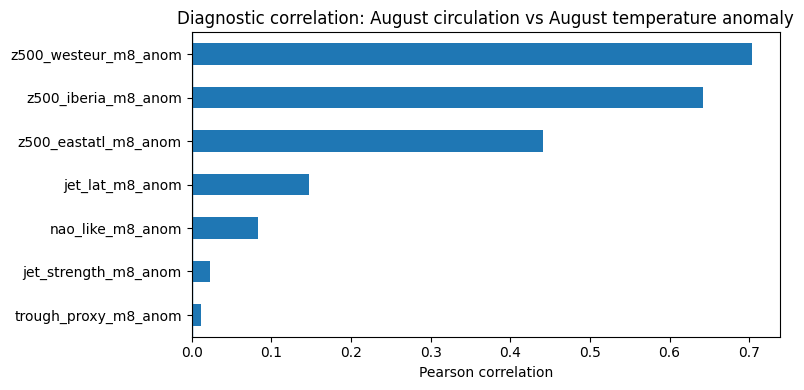

In [ ]:

diagnostic_features = [
    f"z500_iberia_m{TARGET_MONTH}_anom",
    f"z500_westeur_m{TARGET_MONTH}_anom",
    f"z500_eastatl_m{TARGET_MONTH}_anom",
    f"trough_proxy_m{TARGET_MONTH}_anom",
    f"nao_like_m{TARGET_MONTH}_anom",
    f"jet_lat_m{TARGET_MONTH}_anom",
    f"jet_strength_m{TARGET_MONTH}_anom",
]

corr_diag = df[diagnostic_features + ["T_aug_anom_C"]].corr()["T_aug_anom_C"].drop("T_aug_anom_C")
corr_diag = corr_diag.sort_values()

display(corr_diag.to_frame("corr_with_Aug_T"))

plt.figure(figsize=(8, 4))
corr_diag.plot(kind="barh")
plt.axvline(0, linewidth=1)
plt.title("Diagnostic correlation: August circulation vs August temperature anomaly")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()



## 6. Predictive correlations: July circulation vs August temperature

This is closer to a real pre-August forecast.  
Skill is expected to be modest: seasonal/subseasonal prediction is hard.

The purpose is not to claim certainty, but to quantify whether July circulation carries information about August anomalies.


,corr_with_following_Aug_T
jet_lat_m7_anom,-0.065443
nao_like_m7_anom,-0.022165
jet_strength_m7_anom,0.008496
z500_eastatl_m7_anom,0.062725
trough_proxy_m7_anom,0.196798
z500_westeur_m7_anom,0.336735
z500_iberia_m7_anom,0.385791


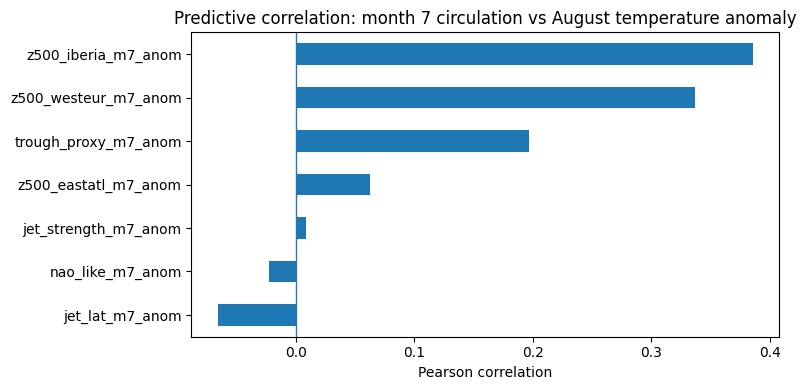

In [ ]:

predictor_features = [
    f"z500_iberia_m{PREDICTOR_MONTH}_anom",
    f"z500_westeur_m{PREDICTOR_MONTH}_anom",
    f"z500_eastatl_m{PREDICTOR_MONTH}_anom",
    f"trough_proxy_m{PREDICTOR_MONTH}_anom",
    f"nao_like_m{PREDICTOR_MONTH}_anom",
    f"jet_lat_m{PREDICTOR_MONTH}_anom",
    f"jet_strength_m{PREDICTOR_MONTH}_anom",
]

corr_pred = df[predictor_features + ["T_aug_anom_C"]].corr()["T_aug_anom_C"].drop("T_aug_anom_C")
corr_pred = corr_pred.sort_values()

display(corr_pred.to_frame("corr_with_following_Aug_T"))

plt.figure(figsize=(8, 4))
corr_pred.plot(kind="barh")
plt.axvline(0, linewidth=1)
plt.title(f"Predictive correlation: month {PREDICTOR_MONTH} circulation vs August temperature anomaly")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()



## 7. Time series of August temperature anomalies

This shows how unusual a cold August would be relative to 1991–2020.


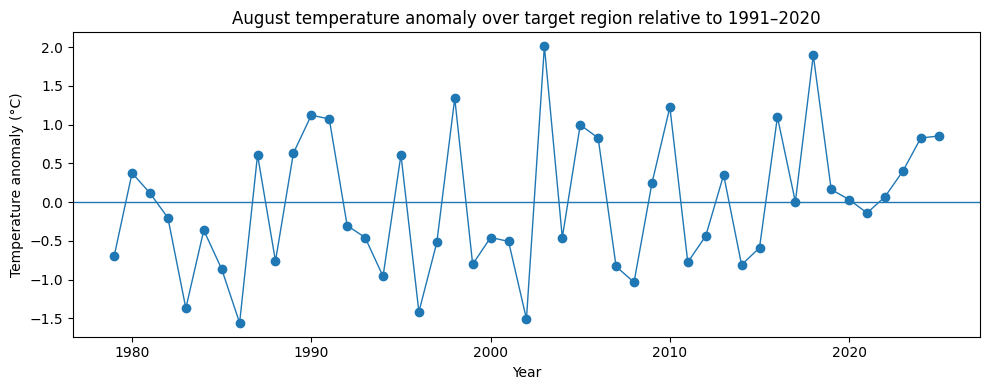

In [ ]:

plt.figure(figsize=(10, 4))
df["T_aug_anom_C"].plot(marker="o", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("August temperature anomaly over target region relative to 1991–2020")
plt.ylabel("Temperature anomaly (°C)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()



## 8. Simple prediction model

We fit a regularized linear model:

`T_August_anomaly ≈ a0 + a1 X1 + a2 X2 + ...`

where `X` are circulation predictors from July.

The notebook also estimates:

`P(cold August) = P(T_August_anomaly < 0)`

using the model prediction and an empirical residual spread.

This probability is **not an official forecast probability**. It is a transparent model-based indicator.


Leave-one-out correlation: 0.14
Leave-one-out RMSE: 0.92 °C
Residual sigma used for probability estimate: 0.93 °C


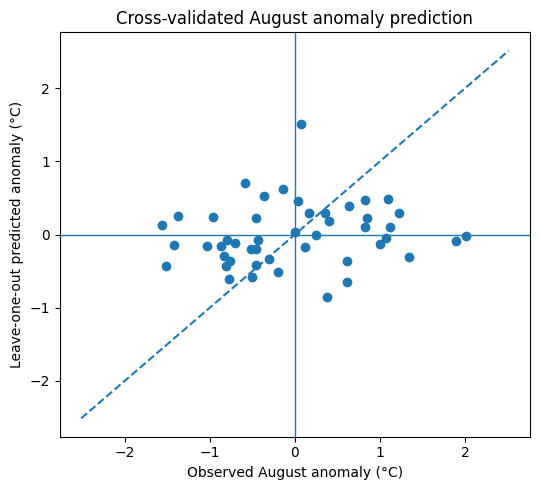

In [ ]:

X = df[predictor_features].copy()
y = df["T_aug_anom_C"].copy()

# Drop missing rows, if any.
valid = X.notna().all(axis=1) & y.notna()
X = X.loc[valid]
y = y.loc[valid]

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 25), cv=LeaveOneOut())
)

model.fit(X, y)

# Cross-validated predictions to estimate skill.
y_cv = cross_val_predict(model, X, y, cv=LeaveOneOut())

skill_corr = np.corrcoef(y, y_cv)[0, 1]
rmse = np.sqrt(np.mean((y - y_cv) ** 2))
resid_sigma = np.std(y - y_cv, ddof=1)

print(f"Leave-one-out correlation: {skill_corr:.2f}")
print(f"Leave-one-out RMSE: {rmse:.2f} °C")
print(f"Residual sigma used for probability estimate: {resid_sigma:.2f} °C")

plt.figure(figsize=(5.5, 5))
plt.scatter(y, y_cv)
lim = max(abs(y).max(), abs(y_cv).max()) + 0.5
plt.plot([-lim, lim], [-lim, lim], linestyle="--")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Observed August anomaly (°C)")
plt.ylabel("Leave-one-out predicted anomaly (°C)")
plt.title("Cross-validated August anomaly prediction")
plt.tight_layout()
plt.show()



## 9. Predict the current August from current-year July indicators

This cell tries to download current-year July data and estimates August anomaly.

If July data are not yet available on NOAA/PSL, run the notebook later or change `CURRENT_YEAR`.

For an August-to-date nowcast, set `PREDICTOR_MONTH = 8` at the top and optionally modify the code to use `day_max`.


In [ ]:

def compute_current_predictor_row(year=CURRENT_YEAR, predictor_month=PREDICTOR_MONTH):
    raw = month_raw_features(year, predictor_month)

    # Convert raw features to anomalies using historical climatology.
    row = {}
    for key, val in raw.items():
        anom_key = key + "_anom"
        if key in clim.index:
            row[anom_key] = val - clim[key]
    return pd.DataFrame([row], index=[year])

try:
    X_current = compute_current_predictor_row(CURRENT_YEAR, PREDICTOR_MONTH)
    X_current = X_current[predictor_features]

    pred_anom = float(model.predict(X_current)[0])
    p_cold = float(norm.cdf((0.0 - pred_anom) / resid_sigma))

    print(f"Current-year predictor month: {PREDICTOR_MONTH}")
    print(f"Predicted August anomaly over target box: {pred_anom:+.2f} °C")
    print(f"Estimated probability of colder-than-1991–2020 August: {100*p_cold:.1f}%")

    display(X_current.T.rename(columns={CURRENT_YEAR: "current_anomaly"}))

except Exception as e:
    print("Could not compute current-year prediction.")
    print("Reason:", e)
    print("Possible causes: current-year data not yet available, temporary NOAA access issue, or missing variables.")


Could not compute current-year prediction.
Reason: All-NaN slice encountered
Possible causes: current-year data not yet available, temporary NOAA access issue, or missing variables.



## 10. Mechanism plot: August Z500 vs August temperature

A simple diagnostic scatterplot:

- high Z500 over Iberia/Western Europe tends to correspond to ridges and warm anomalies;
- low Z500 tends to correspond to troughs and cool anomalies.


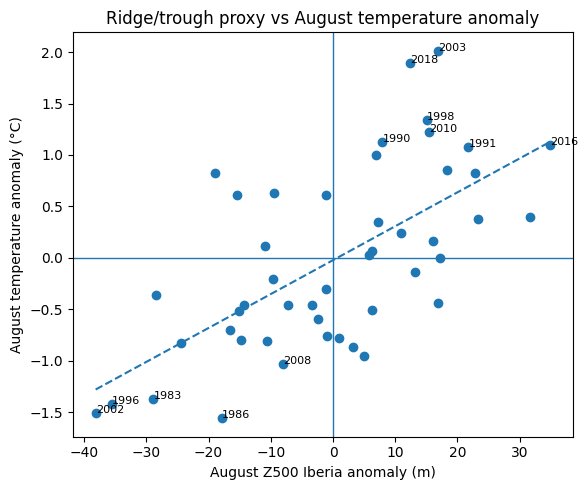

In [ ]:

xcol = f"z500_iberia_m{TARGET_MONTH}_anom"
ycol = "T_aug_anom_C"

plt.figure(figsize=(6, 5))
plt.scatter(df[xcol], df[ycol])
for yr, row in df.iterrows():
    if abs(row[ycol]) > 1.0:
        plt.text(row[xcol], row[ycol], str(yr), fontsize=8)

m, b = np.polyfit(df[xcol].dropna(), df.loc[df[xcol].notna(), ycol], 1)
xx = np.linspace(df[xcol].min(), df[xcol].max(), 100)
plt.plot(xx, m*xx + b, linestyle="--")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("August Z500 Iberia anomaly (m)")
plt.ylabel("August temperature anomaly (°C)")
plt.title("Ridge/trough proxy vs August temperature anomaly")
plt.tight_layout()
plt.show()



## 11. Optional: cold-August composites

This compares average circulation indicators for cold vs warm Augusts.

A more advanced version would produce maps of Z500 anomaly composites.  
Here we keep it lightweight and table-based.


In [ ]:

cold = df[df["cold_august"]]
warm = df[~df["cold_august"]]

summary_cols = diagnostic_features + ["T_aug_anom_C"]

comp = pd.DataFrame({
    "cold_august_mean": cold[summary_cols].mean(),
    "warm_august_mean": warm[summary_cols].mean(),
})
comp["cold_minus_warm"] = comp["cold_august_mean"] - comp["warm_august_mean"]

display(comp)


,cold_august_mean,warm_august_mean,cold_minus_warm
z500_iberia_m8_anom,-9.652665,10.193134,-19.845800
z500_westeur_m8_anom,-11.104944,12.485934,-23.590878
z500_eastatl_m8_anom,-9.593896,13.277307,-22.871203
trough_proxy_m8_anom,-0.058769,-3.084173,3.025404
nao_like_m8_anom,-6.313273,4.552009,-10.865282
jet_lat_m8_anom,-0.020833,1.387681,-1.408514
jet_strength_m8_anom,-0.070758,-0.142846,0.072089
T_aug_anom_C,-0.743366,0.734064,-1.477431



## 12. Interpretation guide

A physically coherent signal for a cool August in Portugal / Western Europe would be:

- negative August or late-July Z500 anomaly near Iberia / Western Europe;
- trough-like circulation over the eastern Atlantic or Iberia;
- jet stream displaced southward or unusually wavy;
- persistent maritime / northerly advection;
- weak subtropical ridge influence;
- possibly negative or blocked NAO-like patterns, depending on the exact spatial phase.

The important distinction is:

`global warming background > 0`

does not imply

`every regional monthly anomaly > 0`

because regional circulation can temporarily dominate:

`T_local = T_background + T_circulation + T_ocean + noise`

A cold August would therefore be a statement about **regional circulation phase**, not a refutation of a warmer background climate.



## 13. Suggested next upgrades

For a stronger scientific version:

1. Replace NCEP with ERA5:
   - 2 m temperature;
   - Z500;
   - U/V at 250 hPa;
   - potential vorticity on isentropic levels or near the dynamical tropopause.
2. Add official NAO/AO indices.
3. Include North Atlantic sea-surface temperature anomalies.
4. Use subseasonal forecast ensembles from ECMWF / C3S if available.
5. Use cross-validated logistic regression for `P(cold August)`.
6. Add maps of Rossby-wave phase and Z500 composites.
7. Test skill separately for Portugal, Iberia, Western Europe, and Northern Europe.
